In [1]:
print('Running imports...')
import os
from captum.attr import IntegratedGradients

os.environ["MKL_THREADING_LAYER"] = "GNU"

import torch # long
from lightning.pytorch import seed_everything
from torch import nn 

import xarray as xr
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import dask.bag as db
import cartopy.crs as ccrs
import argparse
import matplotlib.pyplot as plt
import sys

sys.path.append('/home/rogui7909/code/predict_rain_norway/predict_rain/')

from ml_module_rain.models.trained_models import load_trained_model
from ml_module_rain.models.lightning import ExtremeRainPredictor, AttributableTrainer
from ml_module_rain.models.callbacks import LogF1Validation, get_checkpoint_callback, BestF1Callback



Running imports...


In [2]:
from ml_module_rain.models.lightning import ExtremeRainPredictor, AttributableTrainer
from ml_module_rain.models.callbacks import LogF1Validation, get_checkpoint_callback, BestF1Callback


In [3]:
# run_id = '75kakckt'
# run_id = 'bd4apy6o'
run_id='o08v3553'
# run_id='cx6e235z'
# run_id='t4zwkf7j'
# ima3ba04
samples_to_attribute = 'extr'
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
dataloader, lightning_model = load_trained_model(run_id)

# del dataloader


Seed set to 42


Data ready:
    Image size: 16384 (128x128)
    Input variables: u850, v850, msl
    10958 samples in train
    2922 samples in validation
    2922 samples in test
    7 Predicted timesteps for future rainfall
    Prediction type: boolean_smooth
    What quantile is considered extreme: 95th of all days


In [4]:
trainer = AttributableTrainer(limit_train_batches=100, 
                                max_epochs=1, 
                                logger=None, 
                                log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                                callbacks=[], deterministic=True,
                                accelerator='cuda', devices=1)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [5]:
all_ds_out = []


with torch.no_grad():
    trainer.test(lightning_model, dataloaders=dataloader.train_loader)
predictions_logits = torch.stack(lightning_model.predictions_test)
predictions = torch.nn.functional.sigmoid(predictions_logits).cpu().numpy()
soft_targets = torch.stack(lightning_model.targets_test).cpu().numpy()
targets = soft_targets.copy()
targets[targets<1]=0

ds_predictions = xr.DataArray(predictions, dims=['time', 'timestep'],coords = dict(timestep=dataloader.ds_train.timestep, time=dataloader.ds_train.time[:predictions.shape[0]], ))
ds_targets = xr.DataArray(targets, dims=['time', 'timestep'],coords = dict(timestep=dataloader.ds_train.timestep, time=dataloader.ds_train.time[:predictions.shape[0]], ))
ds_train = xr.Dataset(dict(predictions=ds_predictions, targets=ds_targets)).assign_coords(dataset='train')
all_ds_out.append(ds_train)

with torch.no_grad():
    trainer.test(lightning_model, dataloaders=dataloader.val_loader)
predictions_logits = torch.stack(lightning_model.predictions_test)
predictions = torch.nn.functional.sigmoid(predictions_logits).cpu().numpy()
soft_targets = torch.stack(lightning_model.targets_test).cpu().numpy()
targets = soft_targets.copy()
targets[targets<1]=0

ds_predictions = xr.DataArray(predictions, dims=['time', 'timestep'],coords = dict(timestep=dataloader.ds_val.timestep, time=dataloader.ds_val.time[:predictions.shape[0]], ))
ds_targets = xr.DataArray(targets, dims=['time', 'timestep'],coords = dict(timestep=dataloader.ds_val.timestep, time=dataloader.ds_val.time[:predictions.shape[0]], ))
ds_val = xr.Dataset(dict(predictions=ds_predictions, targets=ds_targets)).assign_coords(dataset='val')
all_ds_out.append(ds_val)


with torch.no_grad():
    trainer.test(lightning_model, dataloaders=dataloader.test_loader)
predictions_logits = torch.stack(lightning_model.predictions_test)
predictions = torch.nn.functional.sigmoid(predictions_logits).cpu().numpy()
soft_targets = torch.stack(lightning_model.targets_test).cpu().numpy()
targets = soft_targets.copy()
targets[targets<1]=0

ds_predictions = xr.DataArray(predictions, dims=['time', 'timestep'],coords = dict(timestep=dataloader.ds_test.timestep, time=dataloader.ds_test.time[:predictions.shape[0]], ))
ds_targets = xr.DataArray(targets, dims=['time', 'timestep'],coords = dict(timestep=dataloader.ds_test.timestep, time=dataloader.ds_test.time[:predictions.shape[0]], ))
ds_test = xr.Dataset(dict(predictions=ds_predictions, targets=ds_targets)).assign_coords(dataset='test')
all_ds_out.append(ds_test)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/loss           1.2569914994739082
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/loss           1.5680196182779902
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/loss           1.5949372516475093
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [6]:
ds_out = xr.concat(all_ds_out, dim='time')
ds_rain = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc')
rain = xr.concat([ds_rain.tp.shift(time=-k).assign_coords(timestep=k) for k in range(7)], dim='timestep')
ds_out['rain'] = rain.sel(time=ds_out.time).assign_coords(timestep=ds_out.timestep)
ds_out.to_netcdf(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_model_skill.nc')

/tmp/ipykernel_1458207/1462261192.py:1: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_out = xr.concat(all_ds_out, dim='time')


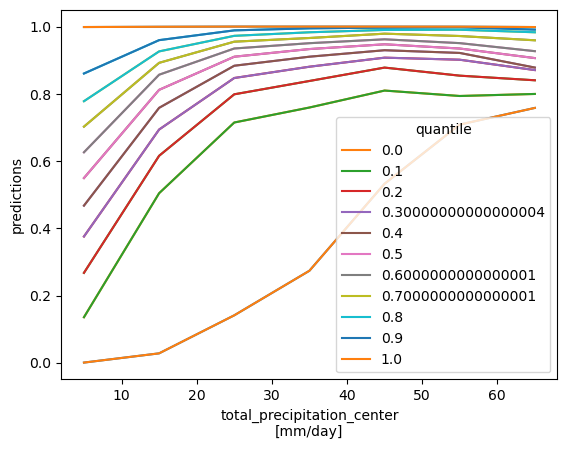

In [18]:
ds_out.predictions.groupby_bins(ds_out.rain, np.arange(0,90,10)).quantile(np.arange(0,1.1,.1)).plot(hue='quantile')#plot.scatter(x='rain', y='predictions')
plt.show()

/tmp/ipykernel_1140291/1963391106.py:1: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_out = xr.concat([all_ds_out[0],all_ds_out[1],all_ds_out[2]], dim='time').sortby('time')


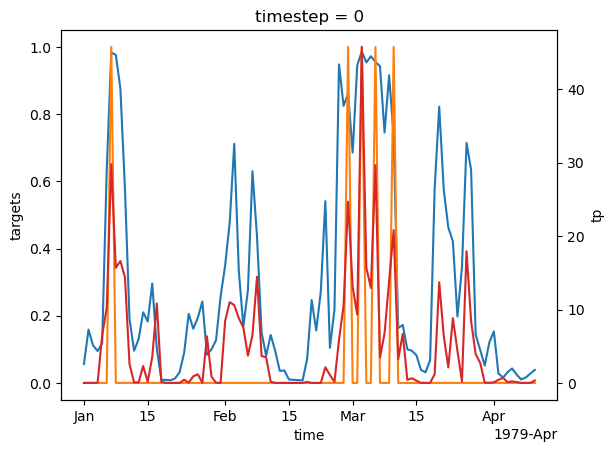

In [7]:
ds_out = xr.concat([all_ds_out[0],all_ds_out[1],all_ds_out[2]], dim='time').sortby('time')
ds_out.isel(timestep=0).isel(time=slice(0,100)).predictions.plot()
ds_out.isel(timestep=0).isel(time=slice(0,100)).targets.plot()
plt.twinx()
ds_rain.isel(time=slice(0,100)).tp.plot(color='C3')

/tmp/ipykernel_1140291/272621715.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_.groupby(pd.cut(df_['rain'], np.arange(0,80,1))).predictions.quantile(.75).plot()
/tmp/ipykernel_1140291/272621715.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_.groupby(pd.cut(df_['rain'], np.arange(0,80,1))).predictions.quantile(.25).plot()
/tmp/ipykernel_1140291/272621715.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
 

<Axes: xlabel='rain'>

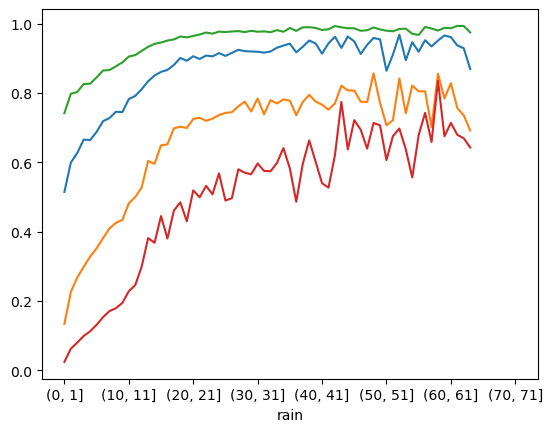

In [17]:
df_ = ds_out.to_dataframe().reset_index()

df_.groupby(pd.cut(df_['rain'], np.arange(0,80,1))).predictions.quantile(.75).plot()
df_.groupby(pd.cut(df_['rain'], np.arange(0,80,1))).predictions.quantile(.25).plot()
df_.groupby(pd.cut(df_['rain'], np.arange(0,80,1))).predictions.quantile(.95).plot()
df_.groupby(pd.cut(df_['rain'], np.arange(0,80,1))).predictions.quantile(.05).plot()